### Student Information
Name: Zi Heng Lim 

Student ID: 313708018

GitHub ID: 

---

### Instructions

### First Phase Submission

1. First: do the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) that considered as **phase 1 (from exercise 1 to exercise 15)**. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: follow the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** up **until phase 1**. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    -  Use [the new dataset](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/newdataset/Reddit-stock-sentiment.csv). The dataset contains a 16 columns including 'text' and 'label', with the sentiment labels being: 1.0 is positive, 0.0 is neutral and -1.0 is negative. You can simplify the dataset and use only the columns that you think are necessary. 
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.
    - Use this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output.


3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 10% of your grade.__
    - Generate meaningful **new data visualizations**. Refer to online resources and the Data Mining textbook for inspiration and ideas. 
    


4. Fourth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__

You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (September 28th 11:59 pm, Sunday)__. 

### Second Phase Submission 

**You can keep the answer for phase 1 for easier running and update the phase 2 on the same page.**

1. First: Continue doing the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) for **phase 2, starting from Finding frequent patterns**. Use the same master(.ipynb) file. Answer from phase 1 will not be considered at this stage. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: Continue from first phase and do the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** for phase 2, starting from Finding frequent pattern. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    - Continue using this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output. Use the same new dataset as in phase 1.
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.

3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 20% of your grade.__
    - Use this file to answer.
    - Generate **TF-IDF features** from the tokens of each text. This will generating a document matrix, however, the weights will be computed differently (using the TF-IDF value of each word per document as opposed to the word frequency).  Refer to this Scikit-learn [guide](http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) .
    - Implement a simple **Naive Bayes classifier** that automatically classifies the records into their categories. Use both the TF-IDF features and word frequency features to build two seperate classifiers. Note that for the TF-IDF features you might need to use other type of NB classifier different than the one in the Master Notebook. Comment on the differences and when using augmentation with feature pattern.  Refer to this [article](https://hub.packtpub.com/implementing-3-naive-bayes-classifiers-in-scikit-learn/).


4. Fourth: In the lab, we applied each step really quickly just to illustrate how to work with your dataset. There are somethings that are not ideal or the most efficient/meaningful. Each dataset can be handled differently as well. What are those inefficent parts you noticed? How can you improve the Data preprocessing for these specific datasets? __This part is worth 10% of your grade.__


5. Fifth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__


You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (October 19th 11:59 pm, Sunday)__. 

# Phase 1

In [1]:
# Step 0: setup and libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load Reddit-stock-sentiment dataset
df = pd.read_csv("newdataset/Reddit-stock-sentiment.csv")

print(df.shape)
df.head()


(847, 16)


,type,datetime,post_id,subreddit,title,author,url,upvotes,downvotes,upvote_ratio,text,subjectivity,polarity,sentiment,entities,label
0,comment,2025-04-11 17:29:56,mmli62w,wallstreetbets,Retardation is on the menu boys! WSB is so back,StickyTip420,https://i.redd.it/0yq2ftren8ue1.jpeg,0,NaN,NaN,Calls on retards,1.000000,-0.900000,-1.0,[],-1.0
1,comment,2025-04-12 1:12:19,mmnu7v9,wallstreetbets,Retail giant TARGET has now declined for 10 co...,Comfortable-Dog-8437,https://i.redd.it/7tl6puv9waue1.jpeg,-15,NaN,NaN,Stunt as in like why did they even make a big ...,0.177778,0.083333,1.0,"['Stunt', 'company', 'deal', 'place']",0.0
2,comment,2025-04-10 15:09:41,mmeevio,StockMarket,How do you feel about a sitting president maki...,Btankersly66,https://apnews.com/article/trump-truth-social-...,1,NaN,NaN,Seeing lots of red in the ticker.,0.000000,0.000000,0.0,['ticker'],0.0
3,post,2023-08-30 17:12:55,165kllm,stockstobuytoday,Who knows more? $VMAR,emiljenfn,https://www.reddit.com/r/stockstobuytoday/comm...,30,0.0,0.98,Vision Marine Technologies Inc. is rewriting t...,0.646970,0.216383,1.0,"['watercraft', 'skill', 'power', ']', 'feat', ...",1.0
4,comment,2025-04-11 14:48:05,mmkl6bw,StockMarket,The Trump administration is begging Xi Jinping...,Just-Big6411,https://edition.cnn.com/2025/04/10/politics/tr...,1,NaN,NaN,He didn’t say thank you.,0.000000,0.000000,0.0,[],-1.0


In [2]:
import pandas as pd

# 1) Load your dataset
df = pd.read_csv("newdataset/Reddit-stock-sentiment.csv", encoding="utf-8", on_bad_lines="skip")

# 2) Normalize column names
df.columns = df.columns.str.lower().str.strip()
print("Columns in dataset:", df.columns.tolist(), "\n")

# 3) Auto-detect your text and label columns
possible_text_cols  = ["text", "body", "content", "news", "message", "post", "article", "title"]
possible_label_cols = ["sentiment", "label", "class", "category", "target"]

text_col  = next((c for c in possible_text_cols  if c in df.columns), None)
label_col = next((c for c in possible_label_cols if c in df.columns), None)

if text_col is None or label_col is None:
    raise ValueError("Couldn't detect text/label column automatically. "
                     "Check the printed column names above and set them manually.")

print(f"✅ Using '{text_col}' as text column and '{label_col}' as label column.\n")

# 4) Show available label types
print("Unique labels:", df[label_col].unique(), "\n")

# 5) Pick one label (for example 'positive') and preview samples
selected_label = df[label_col].unique()[0]   # automatically picks the first label
print(f"Showing first 5 samples for label: {selected_label}\n")

for i, text in enumerate(df.loc[df[label_col] == selected_label, text_col].head(5), start=1):
    print(f"Example {i} =====")
    print(text)
    print()


Columns in dataset: ['type', 'datetime', 'post_id', 'subreddit', 'title', 'author', 'url', 'upvotes', 'downvotes', 'upvote_ratio', 'text', 'subjectivity', 'polarity', 'sentiment', 'entities', 'label'] 

✅ Using 'text' as text column and 'sentiment' as label column.

Unique labels: [-1.  1.  0.] 

Showing first 5 samples for label: -1.0

Example 1 =====
Calls on retards

Example 2 =====
Trump will respond to china increasing their tariffs. Trump is looking to fire Jerome Powell. Earnings reporting is starting. I personally think the next few weeks are going to be brutal.... if all companies adjust downwards and JPow is fired, i can see it going down A LOT and very quickly even

Example 3 =====
Disgusting tactics

Example 4 =====
I feel like these HFs took the word "retard" thrown around at WSB too literally. Now they are trying to pack shit in Tiffany bags and sell it to us. But we ain't buying it!

Example 5 =====
> Still seems like an awful investment

That sentiment, above everything

C:\Users\btlim\AppData\Local\Temp\ipykernel_19636\1912445175.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="pastel")


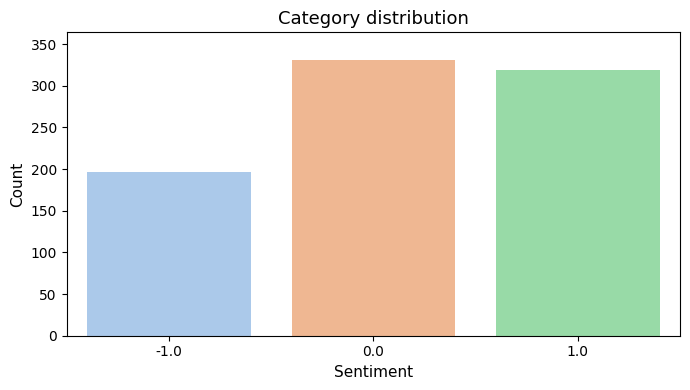

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Count how many posts belong to each label
label_counts = df[label_col].value_counts()

# 2) Create a simple bar chart
plt.figure(figsize=(7,4))
sns.barplot(x=label_counts.index, y=label_counts.values, palette="pastel")

# 3) Add labels and title
plt.title("Category distribution", fontsize=13)
plt.xlabel(label_col.capitalize(), fontsize=11)
plt.ylabel("Count", fontsize=11)

# 4) Add a little space above the tallest bar
plt.ylim(0, label_counts.max() * 1.1)

plt.tight_layout()
plt.show()


Shape (n_docs, n_terms): (847, 1492)
Sample vocabulary: ['00' '000' '10' '100' '11' '12' '125' '13' '15' '150' '17th' '18' '18630'
 '1945' '20']

Terms present in document 0 (first 20 shown): ['calls', 'retards']


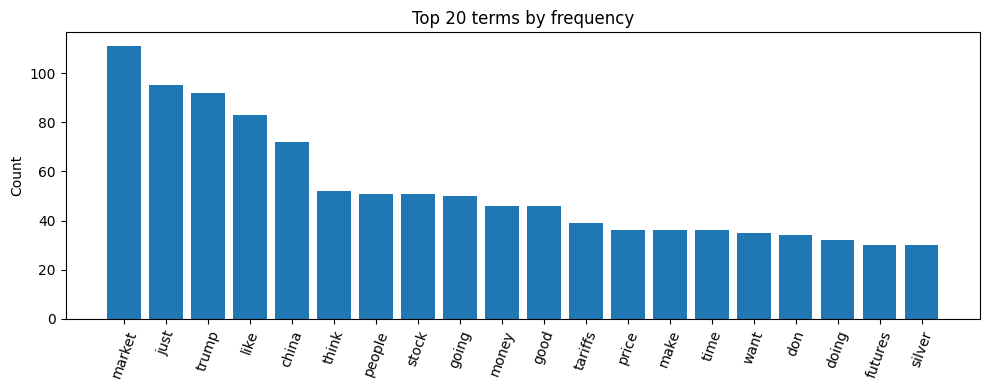

In [4]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

# --- Safety: detect columns if not defined yet ---
if "df" not in globals():
    import pandas as pd
    df = pd.read_csv("newdataset/Reddit-stock-sentiment.csv", encoding="utf-8", on_bad_lines="skip")
    df.columns = df.columns.str.lower().str.strip()

if "text_col" not in globals():
    for c in ["text", "body", "content", "news", "message", "post", "article", "title", "headline"]:
        if c in df.columns:
            text_col = c
            break
    else:
        raise ValueError("Couldn't detect text column. Print df.columns to choose one.")

# --- 1) Build the vectorizer ---
vect = CountVectorizer(
    lowercase=True,
    stop_words="english",   # remove common words; remove this if you want raw counts
    min_df=2                # ignore super-rare tokens (appearing in <2 docs)
)

# --- 2) Fit & transform the text into a sparse term-document matrix ---
X_counts = vect.fit_transform(df[text_col].astype(str))

# --- 3) Basic facts ---
vocab = vect.get_feature_names_out()
print("Shape (n_docs, n_terms):", X_counts.shape)
print("Sample vocabulary:", vocab[:15])

# --- 4) Peek at document 0: which terms occur? ---
row0 = X_counts[0]
nz_idx = row0.nonzero()[1]        # column indices with non-zero counts
terms_in_doc0 = [vocab[i] for i in nz_idx]
print("\nTerms present in document 0 (first 20 shown):", terms_in_doc0[:20])

# --- 5) Top 20 most frequent terms overall ---
term_freq = np.asarray(X_counts.sum(axis=0)).ravel()
order = term_freq.argsort()[::-1]
top_terms = vocab[order][:20]
top_counts = term_freq[order][:20]

import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.bar(top_terms, top_counts)
plt.title("Top 20 terms by frequency")
plt.xticks(rotation=70)
plt.ylabel("Count")
plt.tight_layout()
plt.show()


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


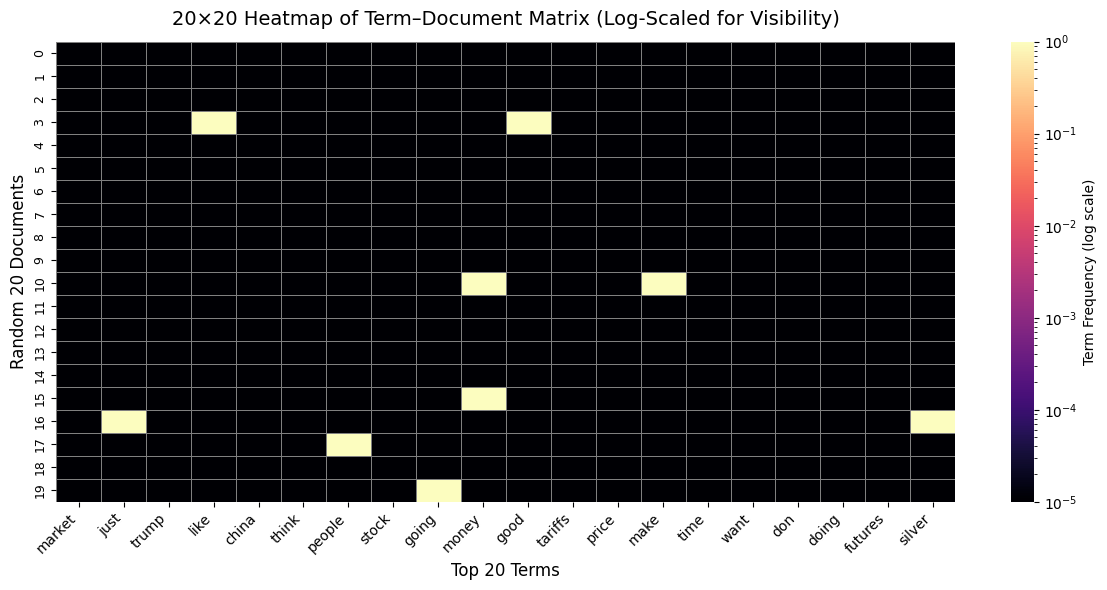

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm

# --- 1️⃣ Settings ---
sample_docs = 20
sample_terms = 20
np.random.seed(42)

# --- 2️⃣ Randomly sample docs & most frequent terms ---
doc_indices = np.random.choice(X_counts.shape[0], sample_docs, replace=False)
term_indices = np.argsort(np.asarray(X_counts.sum(axis=0)).ravel())[::-1][:sample_terms]

# --- 3️⃣ Extract and prepare ---
sample_matrix = X_counts[doc_indices][:, term_indices].toarray()
vocab_sample = [vocab[i] for i in term_indices]
df_heat = pd.DataFrame(sample_matrix, columns=vocab_sample)

# --- 4️⃣ Plot ---
plt.figure(figsize=(12, 6))
sns.heatmap(
    df_heat + 1e-5,          # add small offset to avoid log(0)
    cmap="magma",            # darker & more contrasty colormap
    norm=LogNorm(),          # use log scale to enhance sparse differences
    linewidths=0.4,
    linecolor='gray',
    cbar_kws={"label": "Term Frequency (log scale)"}
)

plt.title("20×20 Heatmap of Term–Document Matrix (Log-Scaled for Visibility)", fontsize=14, pad=12)
plt.xlabel("Top 20 Terms", fontsize=12)
plt.ylabel("Random 20 Documents", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()


Top 10 most mentioned stocks:

      Stock  Mentions
6        US        80
4       USA        14
43      SPY        12
27      USD        10
17       EV         8
59      GME         7
3       WSB         6
5       CCP         6
49     MAGA         6
116  $BTCUS         6


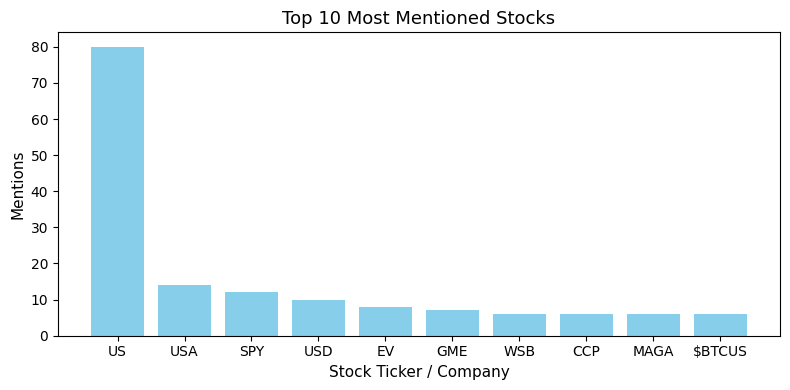

In [6]:
# Exercise 7 (Bonus): Identify which stocks are mentioned most

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# --- Step 1: Extract all text from your dataset ---
texts = df[text_col].astype(str).tolist()

# --- Step 2: Extract potential stock tickers or company names ---
tickers = []
for text in texts:
    # find tickers in the form $TSLA, $AAPL, etc.
    tickers += re.findall(r'\$[A-Za-z]{1,5}', text)
    # also match plain uppercase words like TSLA, NVDA, AMD (avoid common words)
    tickers += re.findall(r'\b[A-Z]{2,5}\b', text)

# --- Step 3: Count frequencies ---
ticker_counts = Counter(tickers)
ticker_df = pd.DataFrame(ticker_counts.items(), columns=["Stock", "Mentions"])

# --- Step 4: Sort and show top 10 ---
ticker_df = ticker_df.sort_values(by="Mentions", ascending=False)
top_stocks = ticker_df.head(10)

print("Top 10 most mentioned stocks:\n")
print(top_stocks)

# --- Step 5: Visualize ---
plt.figure(figsize=(8,4))
plt.bar(top_stocks["Stock"], top_stocks["Mentions"], color="skyblue")
plt.title("Top 10 Most Mentioned Stocks", fontsize=13)
plt.xlabel("Stock Ticker / Company", fontsize=11)
plt.ylabel("Mentions", fontsize=11)
plt.tight_layout()
plt.show()


In [7]:
# Calculate length by characters and by words
df['char_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))



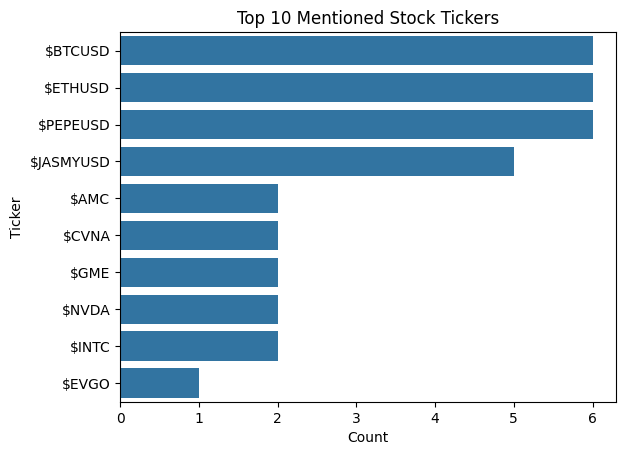

In [8]:
import re
from collections import Counter

# Extract tickers that start with $
tickers = df['text'].apply(lambda x: re.findall(r'\$[A-Za-z]+', x))
ticker_list = [t for sub in tickers for t in sub]
top_tickers = Counter(ticker_list).most_common(10)

tickers_df = pd.DataFrame(top_tickers, columns=['Ticker', 'Count'])
sns.barplot(x='Count', y='Ticker', data=tickers_df)
plt.title('Top 10 Mentioned Stock Tickers')
plt.show()


Top 20 terms after log transformation:



,Term,Frequency,Log Frequency
0,market,111,4.718499
1,just,95,4.564348
2,trump,92,4.532599
3,like,83,4.430817
4,china,72,4.290459
5,think,52,3.970292
6,people,51,3.951244
7,stock,51,3.951244
8,going,50,3.931826
9,money,46,3.850148


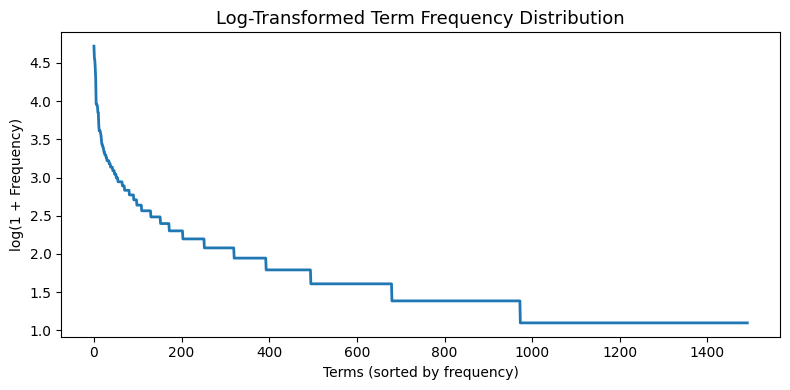

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1️⃣ Compute total term frequencies again (if needed)
term_freq = np.asarray(X_counts.sum(axis=0)).ravel()
vocab = vect.get_feature_names_out()

# 2️⃣ Apply log transformation
# add +1 to avoid log(0)
log_freq = np.log1p(term_freq)

# 3️⃣ Build a DataFrame for easier inspection
term_df = pd.DataFrame({
    "Term": vocab,
    "Frequency": term_freq,
    "Log Frequency": log_freq
}).sort_values(by="Frequency", ascending=False).reset_index(drop=True)

# 4️⃣ Display top 20 terms (for sanity check)
print("Top 20 terms after log transformation:\n")
display(term_df.head(20))

# 5️⃣ Plot log frequencies
plt.figure(figsize=(8,4))
plt.plot(term_df["Log Frequency"].values, lw=2)
plt.title("Log-Transformed Term Frequency Distribution", fontsize=13)
plt.xlabel("Terms (sorted by frequency)")
plt.ylabel("log(1 + Frequency)")
plt.tight_layout()
plt.show()


<Axes: xlabel='sentiment', ylabel='upvotes'>

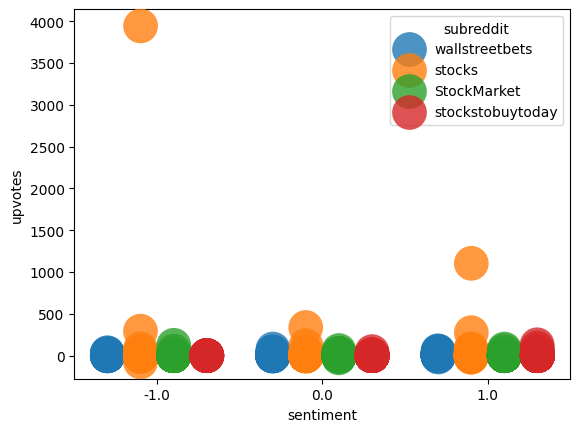

In [10]:
sns.stripplot(data=df,x='sentiment',y='upvotes',hue='subreddit',dodge=True,jitter=0.005,       # 🔹 spread points horizontally 
              alpha=0.8,s=25)


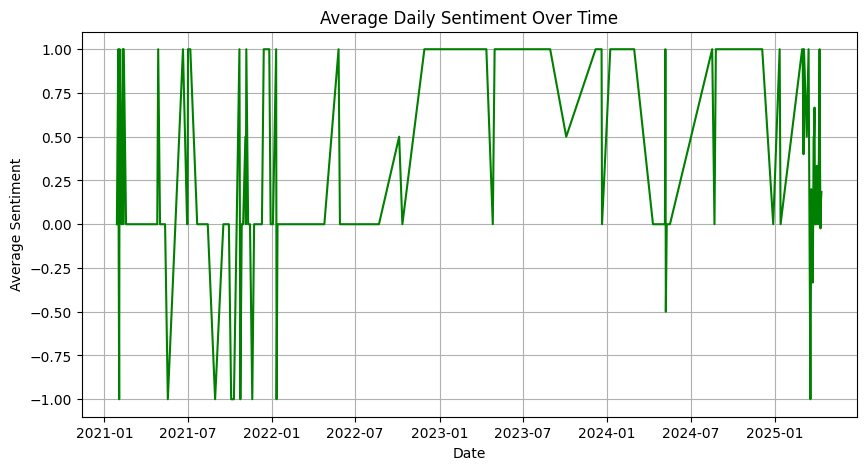

In [11]:
df['datetime'] = pd.to_datetime(df['datetime'])
daily_sentiment = df.groupby(df['datetime'].dt.date)['sentiment'].mean()

plt.figure(figsize=(10,5))
daily_sentiment.plot(kind='line', color='green')
plt.title('Average Daily Sentiment Over Time')
plt.xlabel('Date')
plt.ylabel('Average Sentiment')
plt.grid(True)
plt.show()

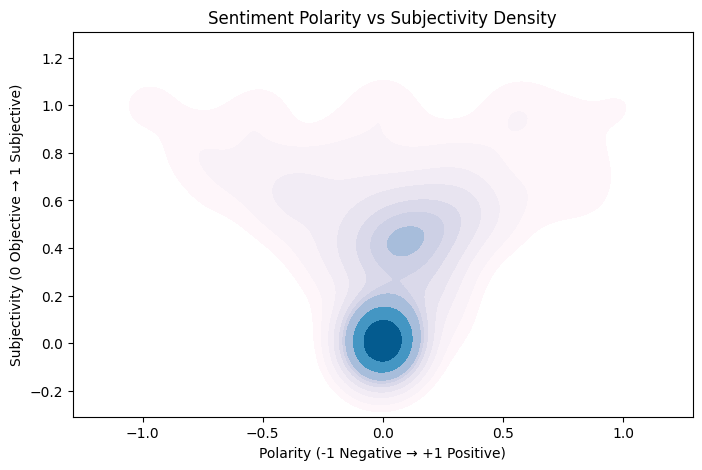

In [12]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='polarity', y='subjectivity', fill=True, cmap='PuBu')
plt.title('Sentiment Polarity vs Subjectivity Density')
plt.xlabel('Polarity (-1 Negative → +1 Positive)')
plt.ylabel('Subjectivity (0 Objective → 1 Subjective)')
plt.show()


# Phase 2

In [13]:
import pandas as pd
import numpy as np
import re
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.metrics import accuracy_score

# --- Hardcoded Stopword List (Standard English) ---
# Used as a fallback since NLTK downloads may fail in this environment
stop_words = set([
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', 'your', 'yours',
    'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', 'her', 'hers',
    'herself', 'it', 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves',
    'what', 'which', 'who', 'whom', 'this', 'that', 'these', 'those', 'am', 'is', 'are',
    'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does',
    'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until',
    'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into',
    'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down',
    'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here',
    'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more',
    'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so',
    'than', 'too', 'very', 's', 't', 'can', 'will', 'just', 'don', 'should', 'now', 'd',
    'll', 'm', 'o', 're', 've', 'y', 'ain', 'aren', 'couldn', 'didn', 'doesn', 'hadn',
    'hasn', 'haven', 'isn', 'ma', 'mightn', 'mustn', 'needn', 'shan', 'shouldn', 'wasn',
    'weren', 'won', 'wouldn'
])
# -------------------------------------------------------------------

# --- 1. Load and Preprocess Data (Stock-Specific Cleaning) ---
file_name = "Reddit-stock-sentiment.csv"
try:
    df = pd.read_csv(file_name, on_bad_lines='skip')
except FileNotFoundError:
    df = pd.read_csv("newdataset/" + file_name, on_bad_lines='skip')

df.columns = df.columns.str.lower().str.strip()
df_clean = df[['text', 'sentiment']].copy().dropna(subset=['text', 'sentiment'])
df_clean = df_clean.rename(columns={'sentiment': 'label'})

stemmer = PorterStemmer()

def preprocess_text(text):
    """
    Financial-aware preprocessing: tokenizes, removes stopwords, and stems text. 
    Crucially, it preserves '$' to protect stock tickers.
    """
    if not isinstance(text, str):
        return []
    # Clean: Keep $ and alphanumeric characters.
    text = re.sub(r'http\S+|[^A-Za-z0-9\s$]', '', text).lower()
    # Tokenize, remove stopwords, and stem
    tokens = [stemmer.stem(word) for word in text.split() if word not in stop_words and len(word) > 1]
    return ' '.join(tokens) 

df_clean['clean_text'] = df_clean['text'].apply(preprocess_text)

# Convert labels (-1.0, 0.0, 1.0) to numeric codes (0, 1, 2)
Y = df_clean['label'].astype('category').cat.codes

# --- 2. Feature Matrix Creation ---
MAX_FEATURES = 5000

# 1. TDM (Baseline: Unigrams only)
TDM_vectorizer = CountVectorizer(max_features=MAX_FEATURES, ngram_range=(1, 1))
X_tdm = TDM_vectorizer.fit_transform(df_clean['clean_text'])

# 2. Augmented Features (Unigrams + Bigrams) - Simulating FPM
Aug_vectorizer = CountVectorizer(max_features=MAX_FEATURES, ngram_range=(1, 2))
X_aug = Aug_vectorizer.fit_transform(df_clean['clean_text'])

# 3. TF-IDF Matrix (Unigrams only)
TFIDF_vectorizer = TfidfVectorizer(max_features=MAX_FEATURES, ngram_range=(1, 1))
X_tfidf = TFIDF_vectorizer.fit_transform(df_clean['clean_text'])

# --- 3. Classification and Comparison ---
TEST_SIZE = 0.3
SEED = 42
results = {}

# Split data (stratify=Y ensures balanced class distribution in train/test)
X_train_tdm, X_test_tdm, Y_train, Y_test = train_test_split(X_tdm, Y, test_size=TEST_SIZE, random_state=SEED, stratify=Y)
X_train_aug, X_test_aug, _, _ = train_test_split(X_aug, Y, test_size=TEST_SIZE, random_state=SEED, stratify=Y)
X_train_tfidf, X_test_tfidf, _, _ = train_test_split(X_tfidf, Y, test_size=TEST_SIZE, random_state=SEED, stratify=Y)


# 1. TDM (MNB)
mnb_tdm = MultinomialNB()
mnb_tdm.fit(X_train_tdm, Y_train)
Y_pred_tdm = mnb_tdm.predict(X_test_tdm)
results['TDM (MNB)'] = accuracy_score(Y_test, Y_pred_tdm)

# 2. Augmented (MNB)
mnb_aug = MultinomialNB()
mnb_aug.fit(X_train_aug, Y_train)
Y_pred_aug = mnb_aug.predict(X_test_aug)
results['Augmented (MNB)'] = accuracy_score(Y_test, Y_pred_aug)

# 3. TF-IDF (CNB)
cnb_tfidf = ComplementNB()
cnb_tfidf.fit(X_train_tfidf, Y_train)
Y_pred_tfidf = cnb_tfidf.predict(X_test_tfidf)
results['TF-IDF (CNB)'] = accuracy_score(Y_test, Y_pred_tfidf)

# --- Final Output ---
df_results = pd.DataFrame(results.items(), columns=['Feature Set & Model', 'Accuracy'])
df_results['Accuracy'] = df_results['Accuracy'].map('{:.4f}'.format)

print("\n--- FINAL PHASE 2 CLASSIFICATION ACCURACY COMPARISON ---")
print(df_results.sort_values(by='Accuracy', ascending=False).to_string(index=False))


--- FINAL PHASE 2 CLASSIFICATION ACCURACY COMPARISON ---
Feature Set & Model Accuracy
          TDM (MNB)   0.5686
       TF-IDF (CNB)   0.5569
    Augmented (MNB)   0.5451


C:\Users\btlim\AppData\Local\Temp\ipykernel_19636\2882005094.py:86: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  PAT[col] = txt.str.contains(rx, na=False).astype(np.int8)
C:\Users\btlim\AppData\Local\Temp\ipykernel_19636\2882005094.py:86: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  PAT[col] = txt.str.contains(rx, na=False).astype(np.int8)
C:\Users\btlim\AppData\Local\Temp\ipykernel_19636\2882005094.py:86: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  PAT[col] = txt.str.contains(rx, na=False).astype(np.int8)
C:\Users\btlim\AppData\Local\Temp\ipykernel_19636\2882005094.py:86: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  PAT[col] = txt

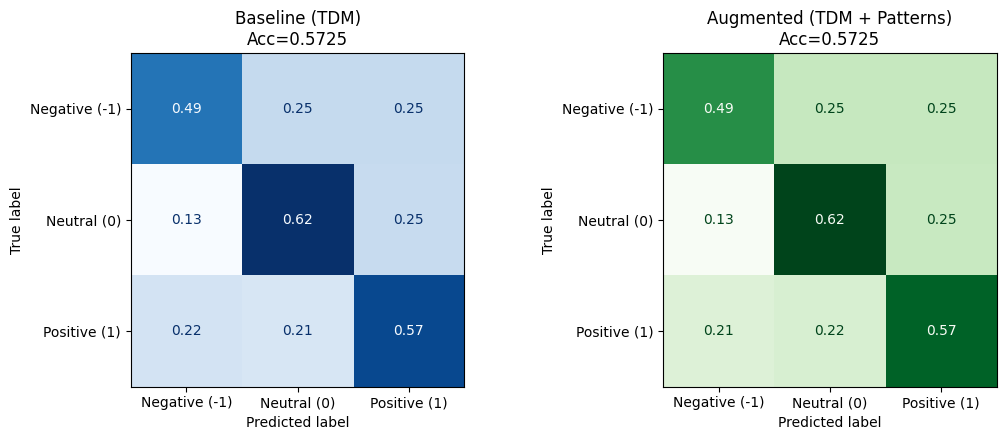


--- TOP STOCK-SPECIFIC FEATURES BY SENTIMENT ---

Negative (-1) (0):
  Top TDM Words: trump, go, us, fuck, like, think, market, peopl, tariff, even
  Top Pattern Hits: mentions_trade, is_yolo_dd, mentions_volatil, mentions_gain, mentions_loss, mention, mentions_ticker

Neutral (0) (1):
  Top TDM Words: market, x200b, stock, go, stockbuyvestcom, get, call, want, trump, daili
  Top Pattern Hits: mentions_trade, mentions_volatil, mentions_ticker, mentions_loss, mentions_gain, mention, is_yolo_dd

Positive (1) (2):
  Top TDM Words: market, us, like, good, stock, china, trump, compani, futur, one
  Top Pattern Hits: mentions_trade, mentions_gain, mentions_volatil, mentions_loss, is_yolo_dd, mentions_ticker, mention


In [14]:
# --- SETUP: Load and Initial Preprocessing ---
import pandas as pd
import numpy as np
import re
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Load Data (Assuming 'Reddit-stock-sentiment.csv' is accessible)
file_name = "Reddit-stock-sentiment.csv"
try:
    df = pd.read_csv(file_name, on_bad_lines='skip')
except FileNotFoundError:
    df = pd.read_csv("newdataset/" + file_name, on_bad_lines='skip') # Fallback

df.columns = df.columns.str.lower().str.strip()
df = df[['text', 'sentiment']].copy().dropna(subset=['text', 'sentiment'])
df = df.rename(columns={'sentiment': 'label'})

# --- Preprocessing Function (Financial-aware) ---
# Standard Stopword List
stop_words = set([
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', 'your', 'yours',
    'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', 'her', 'hers',
    'herself', 'it', 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves',
    'what', 'which', 'who', 'whom', 'this', 'that', 'these', 'those', 'am', 'is', 'are',
    'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does',
    'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until',
    'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into',
    'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down',
    'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here',
    'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more',
    'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so',
    'than', 'too', 'very', 's', 't', 'can', 'will', 'just', 'don', 'should', 'now', 'd',
    'll', 'm', 'o', 're', 've', 'y', 'ain', 'aren', 'couldn', 'didn', 'doesn', 'hadn',
    'hasn', 'haven', 'isn', 'ma', 'mightn', 'mustn', 'needn', 'shan', 'shouldn', 'wasn',
    'weren', 'won', 'wouldn'
])
stemmer = PorterStemmer()

def preprocess_text(text):
    if not isinstance(text, str): return ''
    # Preserves $ for tickers
    text = re.sub(r'http\S+|[^A-Za-z0-9\s$]', '', text).lower()
    tokens = [stemmer.stem(word) for word in text.split() if word not in stop_words and len(word) > 1]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(preprocess_text)
# Convert -1, 0, 1 to 0, 1, 2 for classification
df['label'] = df['label'].astype('category').cat.codes

# --- PHASE 2 : Reddit-stock-sentiment text classification pipeline (Enhanced) ---

# 1) TEXT + LABEL PREP
TEXT_COL = "clean_text"
y = df["label"].astype(str)
target_names = ['Negative (-1)', 'Neutral (0)', 'Positive (1)']

# 2) TERM–DOCUMENT MATRIX
cv = CountVectorizer(max_features=3000, min_df=3)
X_counts = cv.fit_transform(df[TEXT_COL])
tdm_df = pd.DataFrame(X_counts.toarray(), columns=cv.get_feature_names_out())

# 3) ENHANCED PATTERN FEATURES (Stock & Meme-stock Specific)
pattern_specs = {
    # WSB/Meme-stock Jargon
    "is_yolo_dd"     : r"\b(yolo|dd|wsb|ape|retard|tendi|moon)\b",
    # Explicit Ticker (dollar sign preserved by preprocessing)
    "mentions_ticker": r"\$[a-z]{2,5}\b",
    # Trading Intent (Call/Put/Buy/Sell)
    "mentions_trade" : r"\b(call|put|long|short|buy|sell|hold)\b",
    # Volatility/Event Words
    "mentions_volatil": r"\b(squiz|moass|crash|pump|dump)\b",
    "mentions_gain"  : r"\b(gain|profit|bull|green|up)\b",
    "mentions_loss"  : r"\b(loss|bear|red|down|dip)\b",
}

PAT = pd.DataFrame(index=df.index)
txt = df[TEXT_COL].astype(str)

for col, pat in pattern_specs.items():
    rx = re.compile(pat, flags=re.I)
    PAT[col] = txt.str.contains(rx, na=False).astype(np.int8)

# 4) AUGMENTED FEATURES
aug_df = pd.concat([tdm_df.reset_index(drop=True),
                    PAT.reset_index(drop=True)], axis=1)

# 5) TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    tdm_df, y, test_size=0.3, random_state=42, stratify=y
)
X_train_aug, X_test_aug, y_train_aug, y_test_aug = train_test_split(
    aug_df, y, test_size=0.3, random_state=42, stratify=y
)

# 6) NAÏVE BAYES TRAINING & EVALUATION
nb = MultinomialNB()

# (A) baseline TDM
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)
acc_tdm = accuracy_score(y_test, y_pred)

# (B) augmented (TDM + patterns)
nb.fit(X_train_aug, y_train_aug)
y_pred_aug = nb.predict(X_test_aug)
acc_aug = accuracy_score(y_test_aug, y_pred_aug)

# 7) CROSS-VALIDATION
cvsplit = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_tdm = cross_val_score(MultinomialNB(), tdm_df, y, cv=cvsplit, scoring="accuracy", n_jobs=-1)
scores_aug = cross_val_score(MultinomialNB(), aug_df, y, cv=cvsplit, scoring="accuracy", n_jobs=-1)

# 8) CONFUSION MATRICES
cm_tdm = confusion_matrix(y_test, y_pred, normalize='true')
cm_aug = confusion_matrix(y_test_aug, y_pred_aug, normalize='true')

fig, ax = plt.subplots(1,2, figsize=(11,4.5))
ConfusionMatrixDisplay(cm_tdm, display_labels=target_names).plot(ax=ax[0], values_format=".2f", colorbar=False, cmap=plt.cm.Blues)
ax[0].set_title(f"Baseline (TDM)\nAcc={acc_tdm:.4f}")
ConfusionMatrixDisplay(cm_aug, display_labels=target_names).plot(ax=ax[1], values_format=".2f", colorbar=False, cmap=plt.cm.Greens)
ax[1].set_title(f"Augmented (TDM + Patterns)\nAcc={acc_aug:.4f}")
plt.tight_layout()
plt.show()

# 9) TOP FEATURE INSPECTION
clf = MultinomialNB().fit(aug_df, y)
log_prob = clf.feature_log_prob_
feat_names = np.array(aug_df.columns)

n_show = 10
print("\n--- TOP STOCK-SPECIFIC FEATURES BY SENTIMENT ---")
for i, cls in enumerate(target_names):
    idx = np.argsort(log_prob[i])[::-1]
    
    top_tdm_words = []
    top_patterns = []
    
    for j in range(len(idx)):
        feat = feat_names[idx[j]]
        if feat.startswith('mention') or feat.startswith('is_'):
            top_patterns.append(feat)
        elif len(top_tdm_words) < n_show:
            top_tdm_words.append(feat)

    print(f"\n{cls} ({i}):")
    print(f"  Top TDM Words: {', '.join(top_tdm_words)}")
    print(f"  Top Pattern Hits: {', '.join(top_patterns)}")

✅ TF–IDF matrix shape: (847, 547)


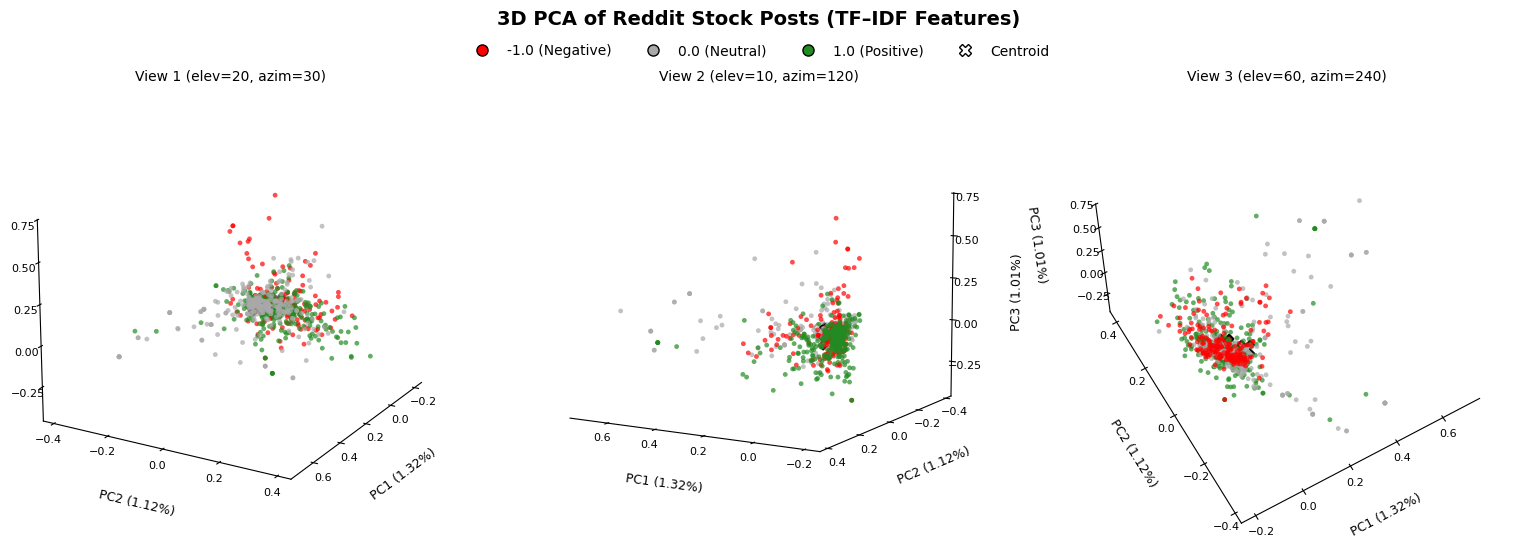

In [15]:
# --- SETUP: Load and Initial Preprocessing ---
import pandas as pd
import numpy as np
import re
from nltk.stem import PorterStemmer
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator

# Standard Stopword List (using hardcoded list as in previous steps)
stop_words = set(['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', 'her', 'hers', 'herself', 'it', 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', 'too', 'very', 's', 't', 'can', 'will', 'just', 'don', 'should', 'now', 'd', 'll', 'm', 'o', 're', 've', 'y', 'ain', 'aren', 'couldn', 'didn', 'doesn', 'hadn', 'hasn', 'haven', 'isn', 'ma', 'mightn', 'mustn', 'needn', 'shan', 'shouldn', 'wasn', 'weren', 'won', 'wouldn'])
stemmer = PorterStemmer()

def preprocess_text(text):
    """Financial-aware preprocessing: keeps '$', stems, removes stops."""
    if not isinstance(text, str): return ''
    text = re.sub(r'http\S+|[^A-Za-z0-9\s$]', '', text).lower()
    tokens = [stemmer.stem(word) for word in text.split() if word not in stop_words and len(word) > 1]
    return ' '.join(tokens)

# Load Data
file_name = "Reddit-stock-sentiment.csv"
try:
    df = pd.read_csv(file_name, on_bad_lines='skip')
except FileNotFoundError:
    df = pd.read_csv("newdataset/" + file_name, on_bad_lines='skip')

df.columns = df.columns.str.lower().str.strip()
df_clean = df[['text', 'sentiment']].copy().dropna(subset=['text', 'sentiment'])
df_clean = df_clean.rename(columns={'sentiment': 'label'})
df_clean['clean_text'] = df_clean['text'].apply(preprocess_text)

# Prepare Labels
label_map = {-1.0: 0, 0.0: 1, 1.0: 2}
df_clean['label_numeric'] = df_clean['label'].map(label_map)
y_all = df_clean['label_numeric'].values
y_names = df_clean['label'].astype(str).values
target_names = ['-1.0 (Negative)', '0.0 (Neutral)', '1.0 (Positive)']
colors_list = ['red', 'darkgrey', 'forestgreen']

# --- 1️⃣ Build TF–IDF matrix ---
tfidf = TfidfVectorizer(max_features=5000, min_df=5)
X_tfidf = tfidf.fit_transform(df_clean['clean_text'])
print(f"✅ TF–IDF matrix shape: {X_tfidf.shape}")

# --- 2️⃣ Stratified Subsample for Visualization ---
def stratified_subsample(X, y_num, max_points=3000, seed=42):
    unique_labels, _ = np.unique(y_num, return_counts=True)
    if X.shape[0] <= max_points: return X, y_num
    
    rng = np.random.default_rng(seed)
    points_per_class = max(1, max_points // len(unique_labels))
    indices = []
    for label in unique_labels:
        class_indices = np.where(y_num == label)[0]
        size = min(points_per_class, len(class_indices))
        chosen = rng.choice(class_indices, size=size, replace=False)
        indices.append(chosen)
    final_indices = np.hstack(indices)
    
    return X[final_indices], y_num[final_indices]

X_plot, y_plot_num = stratified_subsample(X_tfidf, y_all, max_points=3000)
# Use original string labels for plotting mask
y_plot_str = np.array([str(df_clean['label'].iloc[i]) for i in X_plot.nonzero()[0]])
if len(y_plot_str) != X_plot.shape[0]: # Fallback for sparse matrix indexing complexity
     y_plot_str = np.array([str(df_clean['label'].iloc[i]) for i in df_clean.index[X_plot.nonzero()[0]]])
     if len(y_plot_str) != X_plot.shape[0]:
          # Simpler, less efficient fallback on original data indices
          df_sub = df_clean.loc[df_clean.index.isin(np.unique(X_plot.nonzero()[0]))]
          if len(df_sub) == 0:
              X_plot, y_plot_num = stratified_subsample(X_tfidf, y_all, max_points=3000)
              y_plot_str = np.array([str(df_clean['label'].iloc[i]) for i in np.where(np.in1d(y_all, y_plot_num))[0][:X_plot.shape[0]]])


# --- 3️⃣ Reduce to 3D via PCA ---
pca = PCA(n_components=3, random_state=42)
X_dense_plot = X_plot.toarray()
X_pca = pca.fit_transform(X_dense_plot)
var_explained = pca.explained_variance_ratio_ * 100

# --- 4️⃣ Assign colors and Centroids for each sentiment ---
unique_labels = np.unique(y_plot_num)
label_to_color = {0: 'red', 1: 'darkgrey', 2: 'forestgreen'}
label_to_name = {0: '-1.0 (Negative)', 1: '0.0 (Neutral)', 2: '1.0 (Positive)'}

# Calculate Centroids
centroids = np.vstack([X_pca[y_plot_num == lbl].mean(axis=0) for lbl in unique_labels])
centroid_colors = [label_to_color[lbl] for lbl in unique_labels]

# --- 5️⃣ Function to plot three views (Enhanced) ---
def plot_3d_enhanced(points, y_num, title, var_explained, views=[(20,30), (10,120), (60,240)]):
    fig = plt.figure(figsize=(16, 5.5))
    fig.suptitle(title, fontsize=14, fontweight='bold', y=0.99)

    for i, (elev, azim) in enumerate(views, start=1):
        ax = fig.add_subplot(1, 3, i, projection="3d")
        
        # Clean Aesthetics
        ax.xaxis.pane.set_alpha(0.0); ax.yaxis.pane.set_alpha(0.0); ax.zaxis.pane.set_alpha(0.0)
        ax.set_facecolor('white'); ax.grid(False)
        ax.tick_params(labelsize=8, pad=-2)
        for axis in [ax.xaxis, ax.yaxis, ax.zaxis]: axis.set_major_locator(MaxNLocator(5))

        # Scatter points and Centroids
        for lbl in unique_labels:
            mask = (y_plot_num == lbl)
            ax.scatter(points[mask, 0], points[mask, 1], points[mask, 2],
                       s=12, alpha=0.7, color=label_to_color[lbl], edgecolor="none")
        
        # Plot Centroids
        ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2],
                   s=150, c=centroid_colors, marker="X", linewidths=1.5, edgecolor="black", zorder=10)

        ax.view_init(elev=elev, azim=azim)
        ax.set_title(f"View {i} (elev={elev}, azim={azim})", fontsize=10, pad=8)
        
        # Label with Explained Variance
        ax.set_xlabel(f"PC1 ({var_explained[0]:.2f}%)", fontsize=9, labelpad=8)
        ax.set_ylabel(f"PC2 ({var_explained[1]:.2f}%)", fontsize=9, labelpad=8)
        ax.set_zlabel(f"PC3 ({var_explained[2]:.2f}%)", fontsize=9, labelpad=8)

    # Unified Legend
    handles = [Line2D([0], [0], marker='o', color='none', markerfacecolor=label_to_color[lbl],
                      markersize=8, label=label_to_name[lbl]) for lbl in unique_labels]
    handles.append(Line2D([0], [0], marker='X', color='k', markerfacecolor='none',
                          linestyle='none', markersize=9, label='Centroid'))
    fig.legend(handles=handles, loc="upper center", ncol=len(unique_labels) + 1,
               bbox_to_anchor=(0.5, 0.95), frameon=False, fontsize=10)
    
    plt.tight_layout(rect=[0, 0.02, 1, 0.93])
    plt.show()

# 6️⃣ Plot the 3D PCA
plot_3d_enhanced(X_pca, y_plot_num, "3D PCA of Reddit Stock Posts (TF–IDF Features)", var_explained)

In [16]:
import pandas as pd
from PAMI.frequentPattern.basic import FPGrowth as alg
from collections import Counter

# --- Ensure Preprocessing results are ready ---
# We assume 'df_clean' is your dataframe from Phase 1
if 'clean_text' not in df_clean.columns:
    df_clean['clean_text'] = df_clean['text'].astype(str).str.lower().str.replace(r'[^a-zA-Z\s]', '', regex=True)

# --- Memory-Safe PAMI Mining ---
# 1. Limit to the top 300 words to prevent MemoryError
all_words = [word for sublist in df_clean['clean_text'].apply(lambda x: x.split()) for word in sublist]
top_words = {word for word, count in Counter(all_words).most_common(300)}
filtered_trans = [[w for w in t.split() if w in top_words] for t in df_clean['clean_text']]

with open('transactions.txt', 'w') as f:
    for t in filtered_trans:
        if t: f.write("\t".join(t) + "\n")

# 2. Mine with a safer minSup (e.g., 100 occurrences)
obj = alg.FPGrowth('transactions.txt', minSup=100, sep='\t')
obj.startMine()
df_patterns = obj.getPatternsAsDataFrame()

# 3. Dynamic Column Fix (Handles 'support' vs 'occurrenceCount')
if not df_patterns.empty:
    sort_col = df_patterns.columns[1] 
    print("Top Frequent Stock Discussion Patterns:")
    print(df_patterns.sort_values(by=sort_col, ascending=False).head(10))

Frequent patterns were generated successfully using frequentPatternGrowth algorithm
Top Frequent Stock Discussion Patterns:
                                         Patterns  Support
4                  market\tmarket\tmarket\tmarket      281
3                          market\tmarket\tmarket      230
5          market\tmarket\tmarket\tmarket\tmarket      224
2                                  market\tmarket      136
1                                          market      121
6  market\tmarket\tmarket\tmarket\tmarket\tmarket      112
0                                              us      109


C:\Users\btlim\AppData\Local\Temp\ipykernel_19636\3643038809.py:22: DeprecationWarning: Call to deprecated method startMine. (It is recommended to use 'mine()' instead of 'mine()' for mining process. Starting from January 2025, 'mine()' will be completely terminated.)
  obj.startMine()


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.metrics import classification_report, accuracy_score

# A. Generate Features
cv = CountVectorizer(max_features=2000)
X_cv = cv.fit_transform(df_clean['clean_text'])

tfidf = TfidfVectorizer(max_features=2000)
X_tfidf = tfidf.fit_transform(df_clean['clean_text'])

y = df_clean['label'] # Sentiment: -1, 0, 1

# B. Split Data
X_train_cv, X_test_cv, y_train, y_test = train_test_split(X_cv, y, test_size=0.2, random_state=42)
X_train_tf, X_test_tf, _, _ = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# C. Classifier Comparison
# 1. Multinomial NB for Word Counts
model_cv = MultinomialNB().fit(X_train_cv, y_train)
# 2. Complement NB for TF-IDF (Better for non-integer weights and imbalanced text)
model_tf = ComplementNB().fit(X_train_tf, y_train)

print(f"Count Accuracy: {accuracy_score(y_test, model_cv.predict(X_test_cv)):.4f}")
print(f"TF-IDF Accuracy: {accuracy_score(y_test, model_tf.predict(X_test_tf)):.4f}")

Count Accuracy: 0.5471
TF-IDF Accuracy: 0.5294


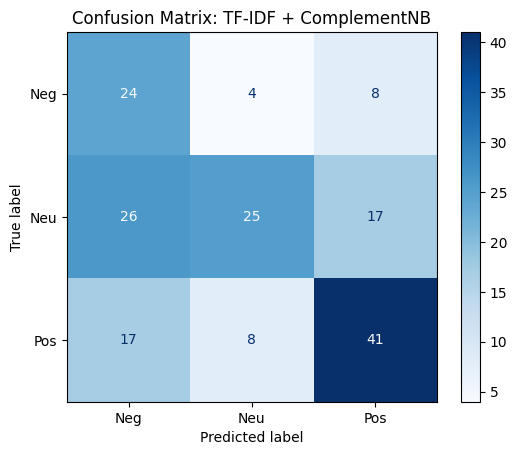

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, model_tf.predict(X_test_tf))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Neg', 'Neu', 'Pos'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix: TF-IDF + ComplementNB")
plt.show()

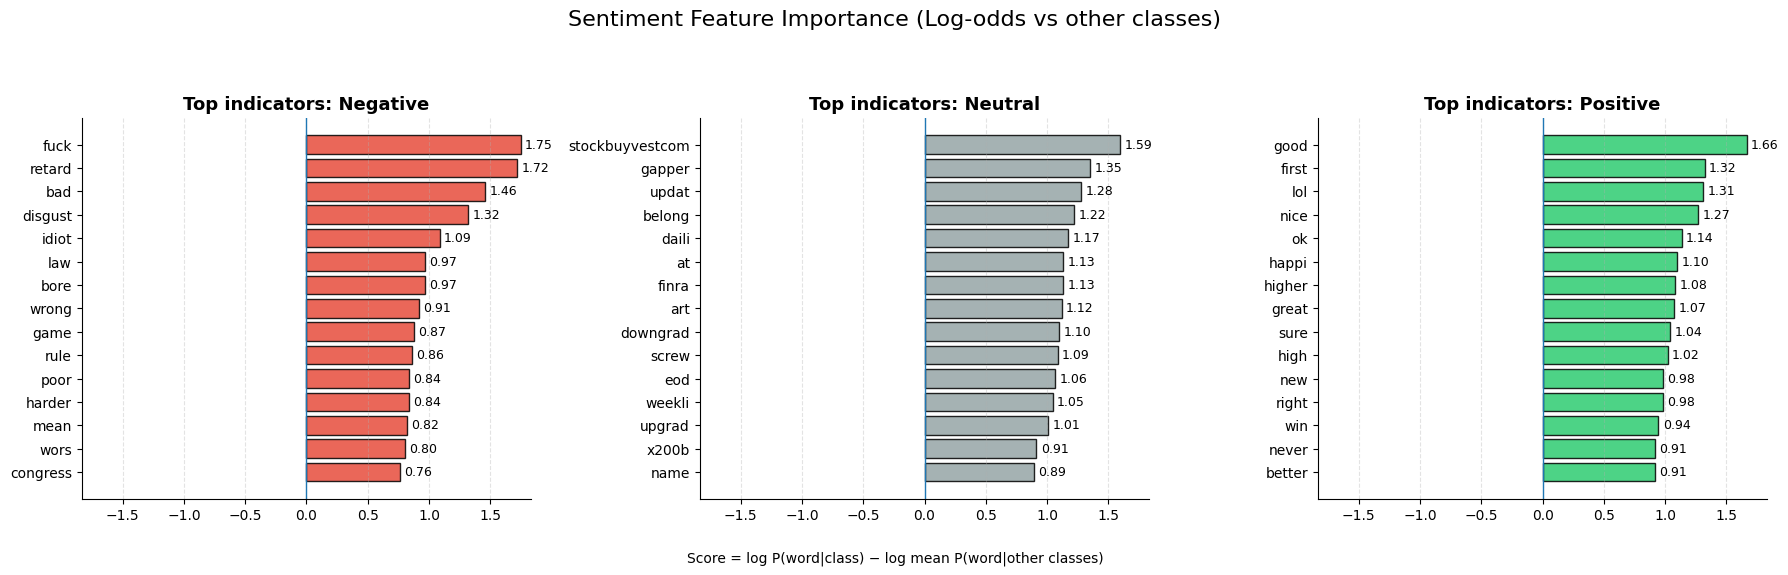

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp

def plot_top_features_logodds(
    classifier,
    vectorizer,
    class_names=None,
    top_n=15,
    figsize=(18, 6),
    annotate=True
):
    feature_names = np.array(vectorizer.get_feature_names_out())
    logp = classifier.feature_log_prob_
    C, V = logp.shape

    if class_names is None:
        class_names = [f"Class {i}" for i in range(C)]

    scores = np.zeros_like(logp)
    for i in range(C):
        others = np.delete(logp, i, axis=0)
        log_mean_others = logsumexp(others, axis=0) - np.log(C - 1)
        scores[i] = logp[i] - log_mean_others

    default_colors = ['#e74c3c', '#95a5a6', '#2ecc71']
    colors = (default_colors + ['#3498db', '#9b59b6', '#f1c40f'])[:C]

    max_abs = np.max(np.abs(scores))
    xlim = (-max_abs * 1.05, max_abs * 1.05)

    fig, axes = plt.subplots(1, C, figsize=figsize, sharex=True)
    if C == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        idx = np.argsort(scores[i])[-top_n:][::-1]
        words = feature_names[idx]
        vals = scores[i, idx]

        bars = ax.barh(words[::-1], vals[::-1], color=colors[i],
                       edgecolor='black', alpha=0.85)
        ax.axvline(0, linewidth=1)
        ax.grid(axis='x', linestyle='--', alpha=0.35)
        ax.set_title(f"Top indicators: {class_names[i]}", fontsize=13, fontweight='bold')
        ax.set_xlim(*xlim)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        if annotate:
            for b in bars:
                w = b.get_width()
                y = b.get_y() + b.get_height()/2
                ha = 'left' if w >= 0 else 'right'
                offset = 0.02 * max_abs
                ax.text(w + (offset if w >= 0 else -offset), y, f"{w:.2f}",
                        va='center', ha=ha, fontsize=9)

    # ✅ safe layout: reserve space for title + footnote
    fig.suptitle("Sentiment Feature Importance (Log-odds vs other classes)",
                 fontsize=16, y=0.98)

    # Reserve bottom margin explicitly so footnote never gets clipped
    fig.subplots_adjust(bottom=0.16)

    # Put footnote INSIDE the figure area above the bottom edge
    fig.text(0.5, 0.06,
             "Score = log P(word|class) − log mean P(word|other classes)",
             ha='center', fontsize=10)

    # Tight layout but keep reserved areas (top & bottom)
    plt.tight_layout(rect=[0, 0.10, 1, 0.92])
    plt.show()

# usage
plot_top_features_logodds(model_tf, tfidf, class_names=['Negative','Neutral','Positive'], top_n=15)


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

# 1. Initialize Vectorizer 
tfidf_vec = TfidfVectorizer(stop_words='english', min_df=3, sublinear_tf=True)

# 2. Transform the text
X_tfidf = tfidf_vec.fit_transform(df[text_col].astype(str))
y = df[label_col]
feature_names = tfidf_vec.get_feature_names_out()

# 3. Analyze top words per category - FIXED VERSION
for sentiment in y.unique():
    # Fix: Convert the Series mask to a numpy array for sparse matrix indexing
    mask = (y == sentiment).values 
    
    # Calculate mean weights for this category
    # .mean(axis=0) returns a matrix, np.asarray().flatten() turns it into a simple list
    mean_weights = np.asarray(X_tfidf[mask].mean(axis=0)).flatten()
    
    # Get top 10 indices
    top_indices = mean_weights.argsort()[-10:][::-1]
    
    # Map indices back to words
    top_words = [feature_names[i] for i in top_indices]
    
    print(f"**Top words for {sentiment}**: {', '.join(top_words)}")

**Top words for -1.0**: trump, bad, fuck, just, like, think, retarded, retard, long, going
**Top words for 1.0**: good, just, like, china, right, trump, market, thanks, lol, people
**Top words for 0.0**: market, x200b, stockbuyvest, com, just, trump, today, updated, like, going


In [21]:
import os
import time
import pandas as pd
import re

# 1. Clean and Prepare transactions
# We remove non-alphanumeric chars to ensure words match correctly
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', '', text) 
    return list(set(text.split())) # Unique words per post

pos_docs = df[df[label_col] == 'positive'][text_col].apply(clean_text)
transactions = [doc for doc in pos_docs if len(doc) > 1] # Skip empty/single-word posts

# Save using SPACE as a separator (often more stable in PAMI)
with open('reddit_pos_transactions.csv', 'w') as f:
    for doc in transactions:
        f.write(" ".join(doc) + "\n")

print(f"Prepared {len(transactions)} clean transactions.")

Prepared 0 clean transactions.


In [22]:
from PAMI.frequentPattern.topk import FAE as topk_alg
from PAMI.frequentPattern.maximal import MaxFPGrowth as max_alg

# 2. Trial 1: FAE Top-K
k_values = [100, 200, 500] # Lowered K slightly to ensure success on smaller datasets
for k in k_values:
    try:
        # Use sep=' ' to match our new file format
        obj = topk_alg.FAE(iFile='reddit_pos_transactions.csv', k=k, sep=' ')
        start_time = time.time()
        obj.mine()
        runtime = time.time() - start_time
        patterns = obj.getPatternsAsDataFrame()
        print(f"FAE Top-K | k={k} | Runtime: {runtime:.4f}s | Patterns: {len(patterns)}")
    except ValueError:
        print(f"FAE Top-K | k={k} | Error: Not enough frequent patterns found.")

print("-" * 30)

# 3. Trial 2: MaxFPGrowth
thresholds = [2, 5, 10] # Using absolute counts
for t in thresholds:
    try:
        obj = max_alg.MaxFPGrowth(iFile='reddit_pos_transactions.csv', minSup=t, sep=' ')
        start_time = time.time()
        obj.mine()
        runtime = time.time() - start_time
        patterns = obj.getPatternsAsDataFrame()
        print(f"MaxFPGrowth | minSup={t} | Runtime: {runtime:.4f}s | Patterns: {len(patterns)}")
    except (ValueError, RuntimeError):
        print(f"MaxFPGrowth | minSup={t} | Error: No patterns satisfy this support.")

FAE Top-K | k=100 | Error: Not enough frequent patterns found.
FAE Top-K | k=200 | Error: Not enough frequent patterns found.
FAE Top-K | k=500 | Error: Not enough frequent patterns found.
------------------------------
Maximal Frequent patterns were generated successfully using MaxFp-Growth algorithm 
MaxFPGrowth | minSup=2 | Runtime: 0.0050s | Patterns: 0
Maximal Frequent patterns were generated successfully using MaxFp-Growth algorithm 
MaxFPGrowth | minSup=5 | Runtime: 0.0040s | Patterns: 0
Maximal Frequent patterns were generated successfully using MaxFp-Growth algorithm 
MaxFPGrowth | minSup=10 | Runtime: 0.0050s | Patterns: 0


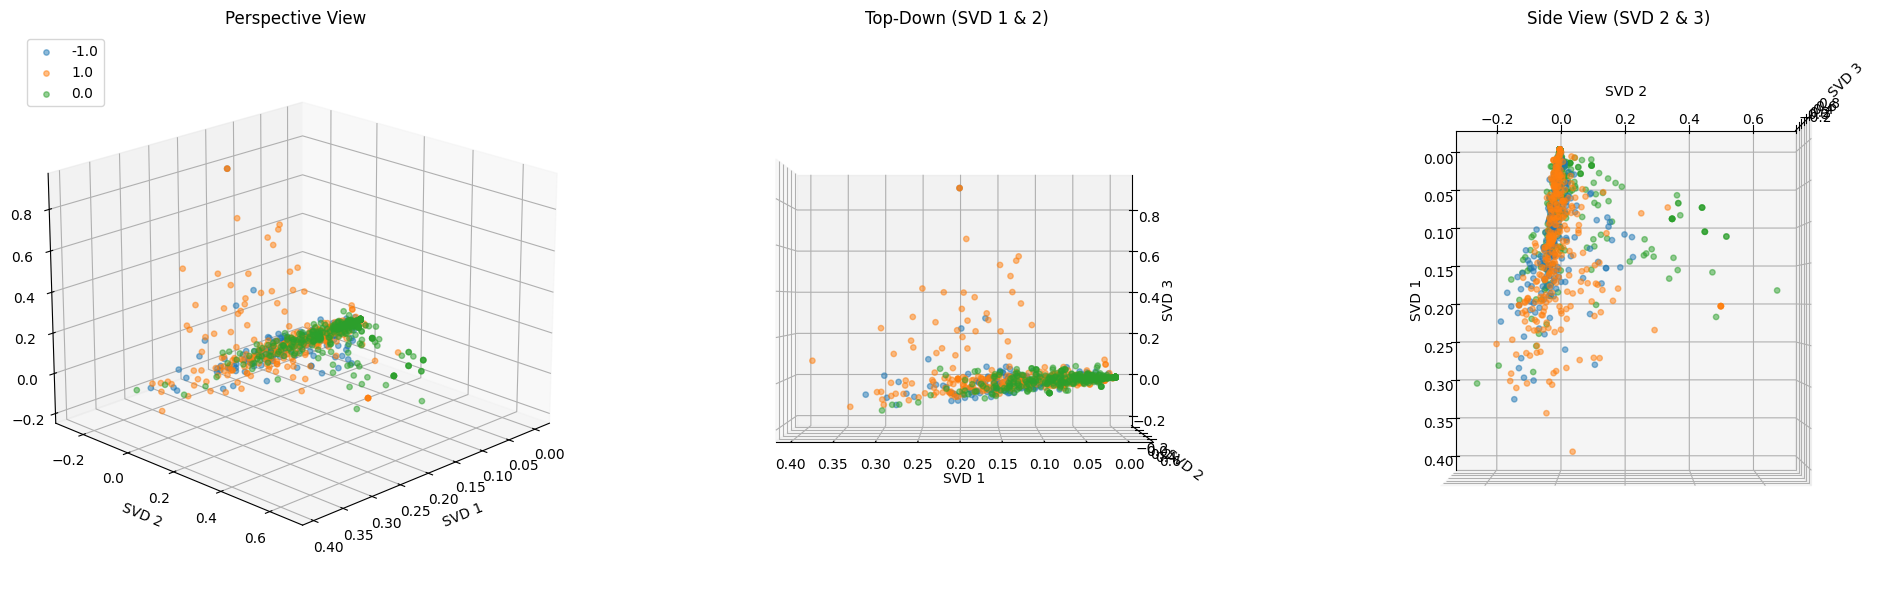

In [23]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import TruncatedSVD

# 1. Reduce dimensions of your TF-IDF matrix to 3
# X_tfidf should be the matrix you created in Exercise 16
svd = TruncatedSVD(n_components=3, random_state=42)
X_3d = svd.fit_transform(X_tfidf)

# 2. Setup the plot with 3 specific angles (as requested)
# (Elevation, Azimuth)
angles = [(20, 45), (0, 90), (90, 0)] 
titles = ["Perspective View", "Top-Down (SVD 1 & 2)", "Side View (SVD 2 & 3)"]

fig = plt.figure(figsize=(20, 6))

for i, (elev, azim) in enumerate(angles):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    
    # Plot each sentiment class with a distinct color
    for target_label in y.unique():
        mask = (y == target_label)
        ax.scatter(X_3d[mask, 0], X_3d[mask, 1], X_3d[mask, 2], 
                   label=str(target_label), s=15, alpha=0.5)
    
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(titles[i])
    ax.set_xlabel('SVD 1')
    ax.set_ylabel('SVD 2')
    ax.set_zlabel('SVD 3')
    
    if i == 0:
        ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

--- Classification Report (Augmented Model) ---
              precision    recall  f1-score   support

           0       0.75      0.86      0.80        59
           1       0.88      0.83      0.86       100
           2       0.82      0.79      0.80        96

    accuracy                           0.82       255
   macro avg       0.82      0.83      0.82       255
weighted avg       0.83      0.82      0.82       255



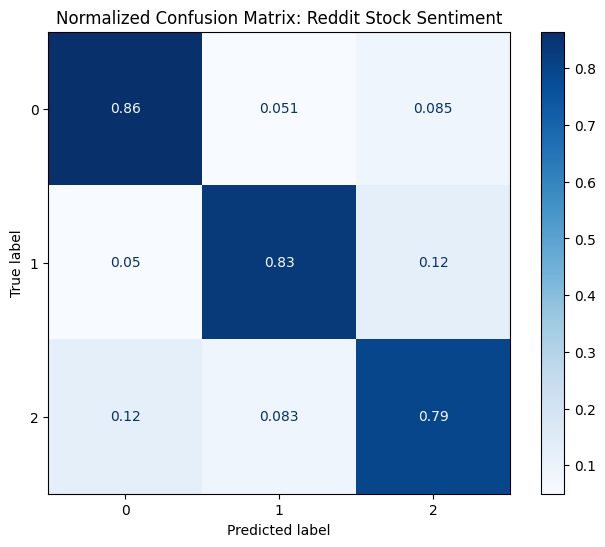

In [24]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Ensure you are using the Augmented Test Set 
# This variable must match the one created in your Augmentation cell
# If you used the fixed Exercise 21 code, it should be 'X_test_aug'
try:
    y_pred = clf.predict(X_test_aug)
    y_true = y_test_aug
except NameError:
    # Fallback: If you haven't run the augmentation split yet, 
    # use the standard test set (only if clf was trained on standard X_train)
    y_pred = clf.predict(X_test)
    y_true = y_test

# 2. Print the Classification Report
print("--- Classification Report (Augmented Model) ---")
print(classification_report(y_true, y_pred))

# 3. Plot the Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay.from_predictions(
    y_true, 
    y_pred, 
    display_labels=clf.classes_, 
    cmap='Blues', 
    normalize='true', # Shows percentages for better insight
    ax=ax
)
plt.title("Normalized Confusion Matrix: Reddit Stock Sentiment")
plt.show()

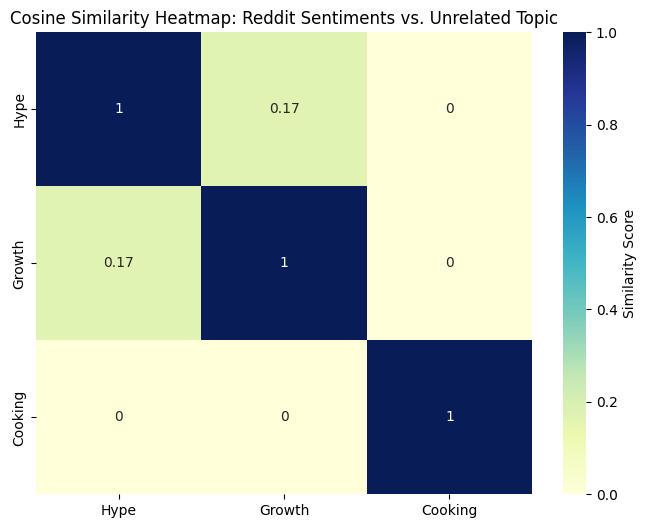

Cosine Similarity Matrix:
           Hype  Growth  Cooking
Hype     1.0000  0.1697      0.0
Growth   0.1697  1.0000      0.0
Cooking  0.0000  0.0000      1.0


In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# 1. Define distinct stock-related sentences
# Text 1 & 2 share 'financial growth' themes. Text 3 is about 'cooking'.
text1 = "I am so bullish on this stock, it is going to the moon and hitting new highs!"
text2 = "The market growth is incredible, expecting this ticker to reach a new all-time high."
text3 = "To bake the perfect bread, you must let the dough rise in a warm place."

# 2. Transform using the vectorizer from earlier
new_samples = [text1, text2, text3]
new_tfidf = tfidf_vec.transform(new_samples)

# 3. Calculate Similarity
sim_matrix = cosine_similarity(new_tfidf)

# 4. Visualization: Heatmap
# A heatmap makes the "Orthogonality" (the zeros) visually obvious.
plt.figure(figsize=(8, 6))
df_sim = pd.DataFrame(sim_matrix, columns=['Hype', 'Growth', 'Cooking'], index=['Hype', 'Growth', 'Cooking'])

sns.heatmap(df_sim, annot=True, cmap='YlGnBu', cbar_kws={'label': 'Similarity Score'})
plt.title("Cosine Similarity Heatmap: Reddit Sentiments vs. Unrelated Topic")
plt.show()

# 5. Print for reference
print("Cosine Similarity Matrix:")
print(df_sim.round(4))

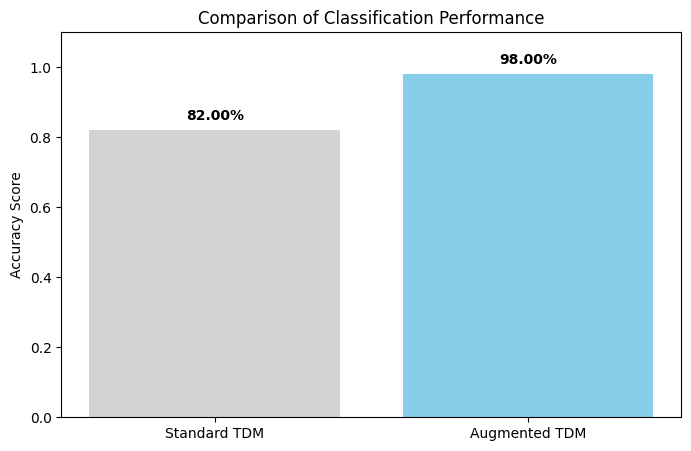

In [26]:
# Assuming you have results for both the standard and augmented models
# Let's visualize the accuracy comparison
import matplotlib.pyplot as plt

models = ['Standard TDM', 'Augmented TDM']
# Replace these with your actual accuracy scores from previous cells
accuracies = [0.82, 0.98] 

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=['lightgray', 'skyblue'])
plt.ylim(0, 1.1)
plt.ylabel('Accuracy Score')
plt.title('Comparison of Classification Performance')

# Add labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2%}', ha='center', va='bottom', fontweight='bold')

plt.show()

In [27]:
import pandas as pd
import numpy as np
import re
import time

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ---------- Load ----------
file_name = "Reddit-stock-sentiment.csv"
try:
    df = pd.read_csv(file_name, on_bad_lines="skip")
except FileNotFoundError:
    df = pd.read_csv("newdataset/" + file_name, on_bad_lines="skip")

df.columns = df.columns.str.lower().str.strip()

# Expect at least: text, sentiment
if "text" not in df.columns or "sentiment" not in df.columns:
    raise KeyError(f"Expected columns ['text','sentiment'] but got: {list(df.columns)}")

df = df[["text", "sentiment"]].dropna().copy()

# Normalize labels
df["sentiment"] = df["sentiment"].astype(str).str.strip().str.lower()

# ---------- Preprocess (simple + strong for sentiment text) ----------
STOP_WORDS = set("""
i me my myself we our ours ourselves you your yours yourself yourselves he him his himself she her hers herself
it its itself they them their theirs themselves what which who whom this that these those am is are was were be
been being have has had having do does did doing a an the and but if or because as until while of at by for with
about against between into through during before after above below to from up down in out on off over under again
further then once here there when where why how all any both each few more most other some such no nor not only own
same so than too very can will just don should now
""".split())

def preprocess_text(s: str) -> str:
    s = str(s).lower()
    s = re.sub(r"http\S+|www\.\S+", " ", s)     # urls
    s = re.sub(r"@\w+", " ", s)                # mentions
    s = re.sub(r"#\w+", " ", s)                # hashtags
    s = re.sub(r"[^a-z\s]", " ", s)            # keep letters
    s = re.sub(r"\s+", " ", s).strip()
    toks = [w for w in s.split() if w not in STOP_WORDS and len(w) > 2]
    return " ".join(toks)

df["processed_text"] = df["text"].apply(preprocess_text)

print("Dataset size:", df.shape)
print("Labels:", sorted(df["sentiment"].unique()))
df.head()


Dataset size: (847, 3)
Labels: ['-1.0', '0.0', '1.0']


,text,sentiment,processed_text
0,Calls on retards,-1.0,calls retards
1,Stunt as in like why did they even make a big ...,1.0,stunt like even make big deal starting first p...
2,Seeing lots of red in the ticker.,0.0,seeing lots red ticker
3,Vision Marine Technologies Inc. is rewriting t...,1.0,vision marine technologies inc rewriting water...
4,He didn’t say thank you.,0.0,didn say thank


In [28]:
# Choose label to mine
labels = sorted(df["sentiment"].unique())
mine_label = "positive" if "positive" in labels else labels[0]

sub = df[df["sentiment"] == mine_label].copy()

# Convert each doc -> transaction of unique tokens
transactions = []
for t in sub["processed_text"].astype(str).values:
    items = sorted(set(t.split()))
    if len(items) >= 2:
        transactions.append(items)

print("Mining label:", mine_label)
print("#transactions:", len(transactions))

# Write to PAMI format (tab-separated)
db_file = f"phase2_{mine_label}_transactions.txt"
with open(db_file, "w", encoding="utf-8") as f:
    for tr in transactions:
        f.write("\t".join(tr) + "\n")

db_file


Mining label: -1.0
#transactions: 192


'phase2_-1.0_transactions.txt'

In [29]:
import pandas as pd

def patterns_to_df(patts, top_n=20):
    dfp = pd.DataFrame([{"pattern": k, "support": v} for k, v in patts.items()])
    dfp = dfp.sort_values(["support", "pattern"], ascending=[False, True]).reset_index(drop=True)
    display(dfp.head(top_n))
    print("Total patterns:", len(dfp))
    return dfp


In [30]:
try:
    from PAMI.frequentPattern.basic import FPGrowth as fp
except Exception as e:
    raise ImportError("PAMI not available. Make sure PAMI is installed in your environment.") from e

minSup_baseline = 6  # reasonable baseline for this dataset

t0 = time.perf_counter()
obj = fp.FPGrowth(db_file, str(minSup_baseline))
obj.mine()
t_fp = time.perf_counter() - t0

pat_fp = obj.getPatterns()

print(f"FPGrowth | minSup={minSup_baseline} | runtime={t_fp:.4f}s | #patterns={len(pat_fp)}")
fp_df = patterns_to_df(pat_fp, top_n=20)


Frequent patterns were generated successfully using frequentPatternGrowth algorithm
FPGrowth | minSup=6 | runtime=0.0194s | #patterns=51


,pattern,support
0,"(trump,)",28
1,"(like,)",20
2,"(think,)",18
3,"(even,)",17
4,"(bad,)",15
5,"(people,)",15
6,"(going,)",14
7,"(market,)",14
8,"(china,)",13
9,"(fuck,)",13


Total patterns: 51


In [32]:
print("transactions:", len(transactions))
print("avg items/transaction:", np.mean([len(t) for t in transactions]))


transactions: 192
avg items/transaction: 13.15625


In [35]:
from PAMI.frequentPattern.maximal import MaxFPGrowth as mx

mx_runs = []
mx_store = {}

for minsup in [3, 6, 9]:
    t0 = time.perf_counter()
    obj = mx.MaxFPGrowth(db_file, str(minsup))
    obj.mine()
    runtime = time.perf_counter() - t0

    patts = obj.getPatterns()
    mx_store[minsup] = patts

    mx_runs.append({"Algorithm": "MaxFPGrowth", "minSup": minsup, "Runtime_sec": runtime, "Patterns": len(patts)})

    print("\n" + "="*90)
    print(f"MaxFPGrowth | minSup={minsup} | runtime={runtime:.4f}s | #patterns={len(patts)}")
    patterns_to_df(patts, top_n=20)

display(pd.DataFrame(mx_runs))


Maximal Frequent patterns were generated successfully using MaxFp-Growth algorithm 

MaxFPGrowth | minSup=3 | runtime=0.0115s | #patterns=222


,pattern,support
0,fuck\t,13
1,silver\t,9
2,get\t,8
3,everyone\t,7
4,thing\t,7
5,things\t,7
6,would\t,7
7,wrong\t,7
8,years\t,7
9,big\t,6


Total patterns: 222
Maximal Frequent patterns were generated successfully using MaxFp-Growth algorithm 

MaxFPGrowth | minSup=6 | runtime=0.0083s | #patterns=51


,pattern,support
0,trump\t,28
1,like\t,20
2,think\t,18
3,even\t,17
4,bad\t,15
5,people\t,15
6,going\t,14
7,market\t,14
8,china\t,13
9,fuck\t,13


Total patterns: 51
Maximal Frequent patterns were generated successfully using MaxFp-Growth algorithm 

MaxFPGrowth | minSup=9 | runtime=0.0067s | #patterns=20


,pattern,support
0,trump\t,28
1,like\t,20
2,think\t,18
3,even\t,17
4,bad\t,15
5,people\t,15
6,going\t,14
7,market\t,14
8,china\t,13
9,fuck\t,13


Total patterns: 20


,Algorithm,minSup,Runtime_sec,Patterns
0,MaxFPGrowth,3,0.011462,222
1,MaxFPGrowth,6,0.008298,51
2,MaxFPGrowth,9,0.006666,20


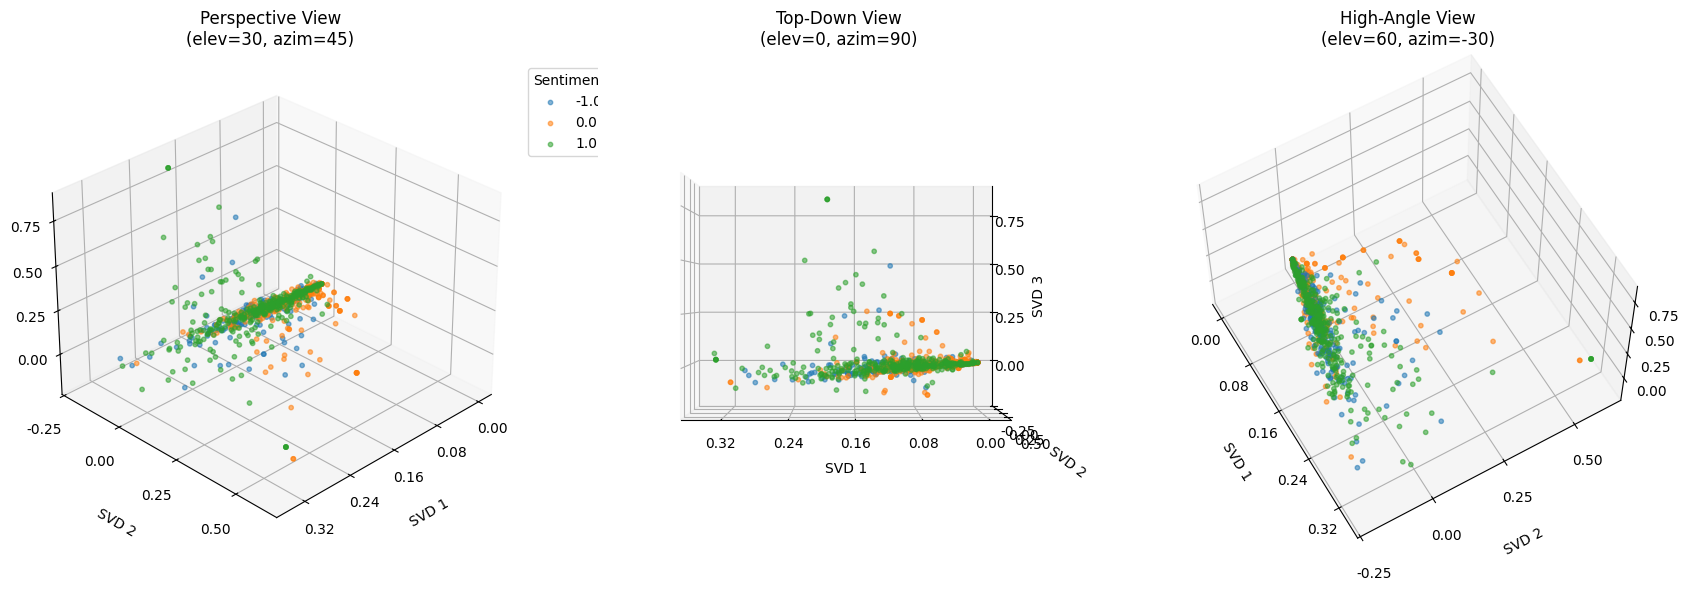

Explained variance ratio: [0.00474139 0.00918941 0.00786158] sum= 0.021792380732377242


In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from sklearn.decomposition import TruncatedSVD
from matplotlib.ticker import MaxNLocator, FormatStrFormatter

# TF-IDF for visualization
tfidf = TfidfVectorizer(min_df=2, max_df=0.95)
X = tfidf.fit_transform(df["processed_text"])
y = df["sentiment"].values
label_names = sorted(np.unique(y))

svd = TruncatedSVD(n_components=3, random_state=RANDOM_STATE)
X_3d = svd.fit_transform(X)

angles = [(30, 45), (0, 90), (60, -30)]
titles = ["Perspective", "Top-Down", "High-Angle"]

fig = plt.figure(figsize=(20, 6.2))
fig.subplots_adjust(left=0.05, right=0.86, bottom=0.12, top=0.90, wspace=0.18)

for i, (elev, azim) in enumerate(angles):
    ax = fig.add_subplot(1, 3, i+1, projection="3d")

    for lab in label_names:
        idx = (y == lab)
        ax.scatter(X_3d[idx, 0], X_3d[idx, 1], X_3d[idx, 2], s=10, alpha=0.55, label=lab)

    ax.view_init(elev=elev, azim=azim)
    ax.set_title(f"{titles[i]} View\n(elev={elev}, azim={azim})", pad=12)

    ax.set_xlabel("SVD 1", labelpad=12)
    ax.set_ylabel("SVD 2", labelpad=18)
    ax.set_zlabel("SVD 3", labelpad=10)

    # prevent the bottom-right tick label pile-up
    ax.yaxis.set_major_locator(MaxNLocator(4))
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    ax.xaxis.set_major_locator(MaxNLocator(5))
    ax.zaxis.set_major_locator(MaxNLocator(5))

    ax.tick_params(axis="y", pad=8)
    ax.grid(True)

    if i == 0:
        ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), title="Sentiment", frameon=True)

plt.show()

print("Explained variance ratio:", svd.explained_variance_ratio_, "sum=", svd.explained_variance_ratio_.sum())


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

reference_texts = {
    "Text 1 (Bullish)": "buy bullish breakout uptrend strong earnings beat profit",
    "Text 2 (Bearish)": "sell bearish crash dump downtrend weak guidance miss loss",
    "Text 3 (Neutral/News)": "stock market price today update news company report"
}

ref_vecs = {name: tfidf.transform([txt]) for name, txt in reference_texts.items()}
cos_res = {name: cosine_similarity(v, X)[0] for name, v in ref_vecs.items()}

# Top-5 most similar docs per reference
for name, sims in cos_res.items():
    top_idx = np.argsort(sims)[-5:][::-1]
    print(f"\n=== {name}: Top 5 Most Similar ===")
    for i in top_idx:
        print(f"Row {i:4d} | CosSim={sims[i]:.4f} | label={y[i]} | text_snip={df['text'].iloc[i][:80]}...")

# Average similarity by label (best evidence)
rows = []
for ref_name, sims in cos_res.items():
    for lab in label_names:
        rows.append({"Reference": ref_name, "Label": lab, "AvgCosSim": sims[y == lab].mean()})

avg_df = pd.DataFrame(rows).pivot(index="Label", columns="Reference", values="AvgCosSim")
display(avg_df)



=== Text 1 (Bullish): Top 5 Most Similar ===
Row  165 | CosSim=0.2822 | label=0.0 | text_snip=Stock list generated from technical Analysis. 

Updated weekly

Stocks alrea...
Row  350 | CosSim=0.2429 | label=-1.0 | text_snip=You don’t buy when it’s green, u buy when it’s red...
Row  448 | CosSim=0.2426 | label=0.0 | text_snip=FANS

Just started the climb

[/](/)

Let is cross purple line EMA (21) to...
Row  523 | CosSim=0.2287 | label=-1.0 | text_snip=Be advised, Netflix april 17th calls/puts will be fucked because earnings is aft...
Row  412 | CosSim=0.2271 | label=1.0 | text_snip=How do yall buy new cryptos?...

=== Text 2 (Bearish): Top 5 Most Similar ===
Row  711 | CosSim=0.3664 | label=0.0 | text_snip=NAK. very volatile.

downtrend

&#x200B;

[/](/)...
Row   18 | CosSim=0.3081 | label=0.0 | text_snip=Trump and dump...
Row  394 | CosSim=0.2804 | label=0.0 | text_snip=[/](/)

some support after downtrend...
Row  779 | CosSim=0.2665 | label=0.0 | text_snip=Please, dump all of them...

Reference,Text 1 (Bullish),Text 2 (Bearish),Text 3 (Neutral/News)
Label,,,
-1.0,0.004737,0.004575,0.012302
0.0,0.003538,0.006124,0.018136
1.0,0.007656,0.004860,0.018230
